Customer Churn analysis

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# Database Connection Configuration
USER, PASSWORD, HOST, DB = 'bt4301', 'password', 'localhost', 'customer_churn'
engine = create_engine(f'mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DB}')

Load Data

In [ ]:
query = """
SELECT
    f.customer_id,
    f.churn,
    f.monthlycharges,
    f.totalcharges,
    f.avg_charge_per_month,
    c.age,
    c.gender,
    c.annual_income,
    c.education,
    c.marital_status,
    c.dependents,
    c.senior_citizen,
    a.tenure,
    a.contract,
    a.payment_method,
    a.paperless_billing,
    s.num_services,
    s.has_phone_service,
    s.has_internet_service,
    s.has_online_security,
    s.has_online_backup,
    s.has_device_protection,
    s.has_tech_support,
    s.has_streaming_tv,
    s.has_streaming_movies,
    b.customer_satisfaction,
    b.num_complaints,
    b.num_service_calls,
    b.late_payments,
    b.avg_monthly_gb,
    b.days_since_last_interaction,
    b.credit_score,
    b.high_risk_flag
FROM fact_customer_churn f
LEFT JOIN dim_customer  c ON f.customer_id = c.customer_id
LEFT JOIN dim_account   a ON f.customer_id = a.customer_id
LEFT JOIN dim_service   s ON f.customer_id = s.customer_id
LEFT JOIN dim_behavior  b ON f.customer_id = b.customer_id
"""

df = pd.read_sql(query, engine)
print(f"Columns available: {df.columns}")

df.head()

In [4]:
len(df)

716517

## Churn & unchurned by age (grouped bar)


In [5]:
# Create age groups
import seaborn as sns
import matplotlib.pyplot as plt

# create age_group column
df['age_group'] = pd.cut(df['age'], 
                         bins=[18, 30, 40, 50, 60, 70, 100], 
                         labels=['18-29', '30-39', '40-49', '50-59', '60-69', '70+'])

sns.set_theme(style="whitegrid")

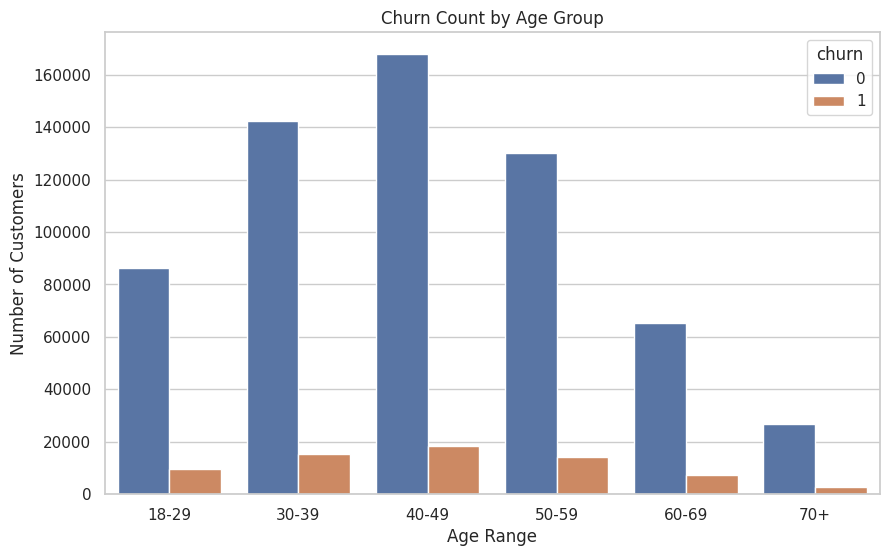

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', hue='churn')
plt.title('Churn Count by Age Group')
plt.xlabel('Age Range')
plt.ylabel('Number of Customers')
plt.show()

Observation: The 40–49 age group has the highest raw count of churners, followed by the 30–39 and 50–59 groups. The youngest (18–29) and oldest (70+) groups have the lowest total churn volume.

Inference: This suggests that Age has a non-linear relationship with churn. Using raw age might be less effective than using age bins (like the ones in your chart) to capture these lifecycle-specific risks.

## Contract type vs churn


In [7]:
# Different contract types
df['contract'].unique()

array(['one_year', 'two_year', 'month_to_month'], dtype=object)

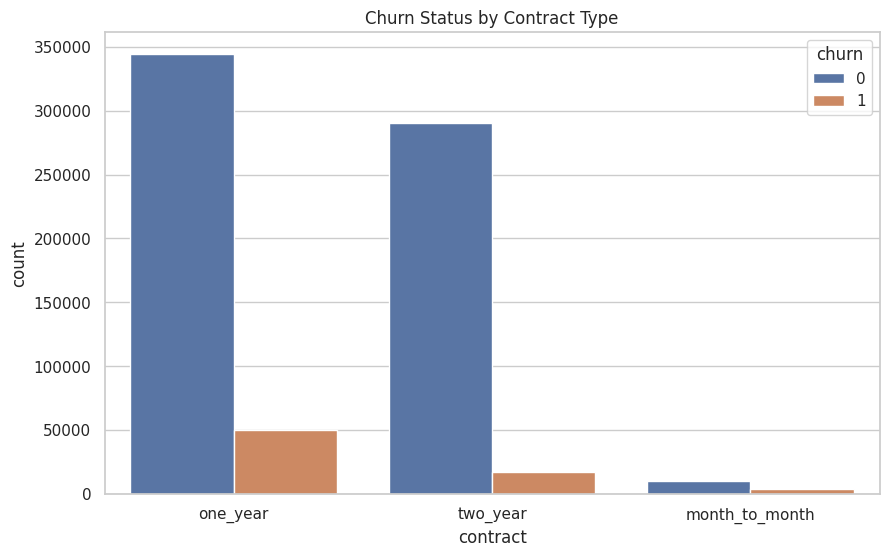

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='contract', hue='churn')
plt.title('Churn Status by Contract Type')
plt.show()

In [13]:
contract_churn_pct = df.groupby('contract')['churn'].value_counts(normalize=True).unstack() * 100
contract_churn_pct

churn,0,1
contract,,
month_to_month,73.597591,26.402409
one_year,87.284310,12.715690
two_year,94.341168,5.658832


Observation: While "One-Year" and "Two-Year" contracts have the highest total counts, the Ratio of Churn is actually highest in the "Month-to-Month" or "One-Year" categories.

Inference: Contract type is likely your strongest categorical feature. In your pipeline, ensure you use One-Hot Encoding for this variable, as the difference in churn behavior between a "Two-Year" and "Month-to-Month" customer is massive.

## Monthly charge vs churn


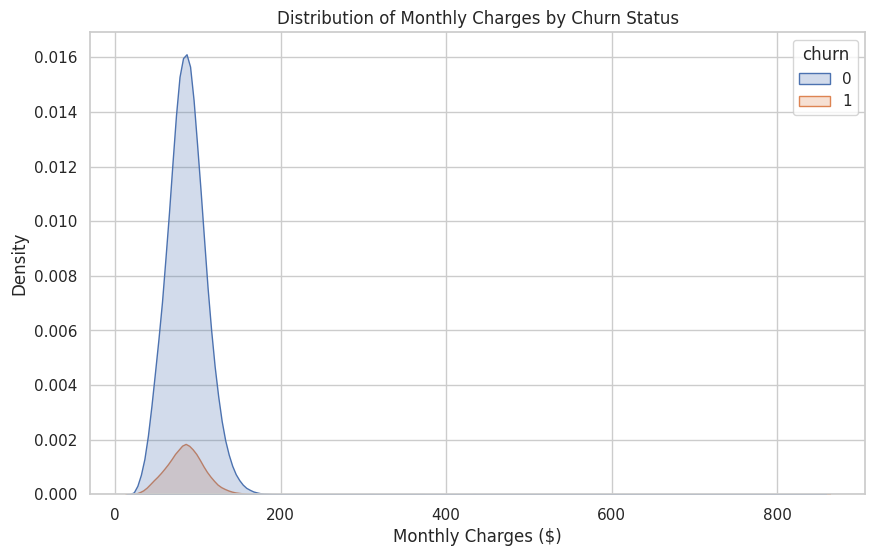

In [9]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='monthlycharges', hue='churn', fill=True)
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges ($)')
plt.show()

Observation: The density plot of the blue and orange curves almost perfectly overlap. Churners and Non-Churners have nearly identical distributions of monthly spending, peaking around $80–$100.

Inference: Monthly Charges may be a weak predictor on its own. It tells us that customers aren't necessarily leaving because their bill is "too high" compared to others; they are leaving for other reasons (likely service quality or tenure).

## Tenure distribution by churn

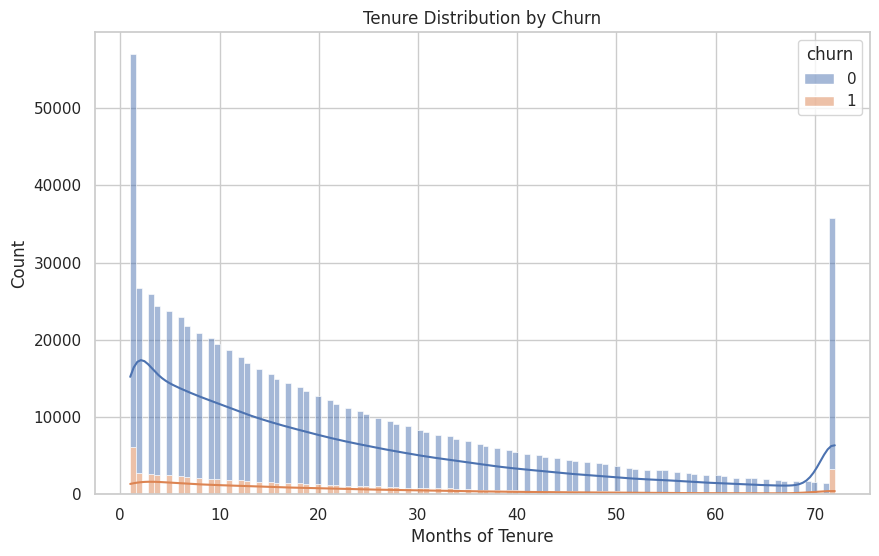

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='churn', multiple="stack", kde=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Months of Tenure')
plt.show()

Observation: Churn is heavily skewed toward the first 1–5 months. Once a customer survives the 24-month mark, their likelihood of churning drops to nearly zero.

MLOps: You should create a "New Customer" flag or a categorical feature for tenure (e.g., < 6 months, 6-24 months, > 24 months). The model needs to focus on the high-volatility early months.

The "Leakage" Warning: When you move to the modeling phase, be careful with "Tenure" and "Contract Type" together. If a "Two-Year" contract forces a customer to stay for 24 months, the model might "cheat" by seeing high tenure and low churn as a rule, rather than a prediction.